In [5]:
from fastai.vision.all import *

In [6]:
path = untar_data(URLs.PETS)/'images'

In [7]:
def is_cat(x): return x[0].isupper() 


In [8]:
dls = ImageDataLoaders.from_name_func('.',
    get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat,
    item_tfms=Resize(192))

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.193612,0.068564,0.024357,08:55


epoch,train_loss,valid_loss,error_rate,time
0,0.082024,0.052517,0.018268,07:54
1,0.044762,0.014461,0.006766,07:40
2,0.015868,0.019960,0.007442,08:25


In [10]:
learn.export('model.pkl')

In [11]:
#Which image models are best?
! git clone --depth 1 https://github.com/rwightman/pytorch-image-models.git
%cd pytorch-image-models/results

C:\Users\modin\OneDrive\Documents\my-internshipML\pytorch-image-models\results


Cloning into 'pytorch-image-models'...


In [12]:
import pandas as pd
df_results = pd.read_csv('results-imagenet.csv')

In [13]:
df_results['model_org'] = df_results['model'] 
df_results['model'] = df_results['model'].str.split('.').str[0]

In [15]:
def get_data(part, col):
    df = pd.read_csv(f'benchmark-{part}-amp-nhwc-pt111-cu113-rtx3090.csv').merge(df_results, on='model')
    df['secs'] = 1. / df[col]
    df['family'] = df.model.str.extract(r'^([a-z]+?(?:v2)?)(?:\d|_|$)')  # ← fixed
    df = df[~df.model.str.endswith('gn')]
    df.loc[df.model.str.contains('in22'),'family'] = df.loc[df.model.str.contains('in22'),'family'] + '_in22'
    df.loc[df.model.str.contains('resnet.*d'),'family'] = df.loc[df.model.str.contains('resnet.*d'),'family'] + 'd'
    return df[df.family.str.contains('^re[sg]netd?|beit|convnext|levit|efficient|vit|vgg|swin')]

In [22]:
df = get_data('infer', 'infer_samples_per_sec')

In [23]:
import plotly.express as px
w,h = 1000,800

def show_all(df, title, size):
    return px.scatter(df, width=w, height=h, size=df[size]**2, title=title,
        x='secs',  y='top1', log_x=True, color='family', hover_name='model_org', hover_data=[size])

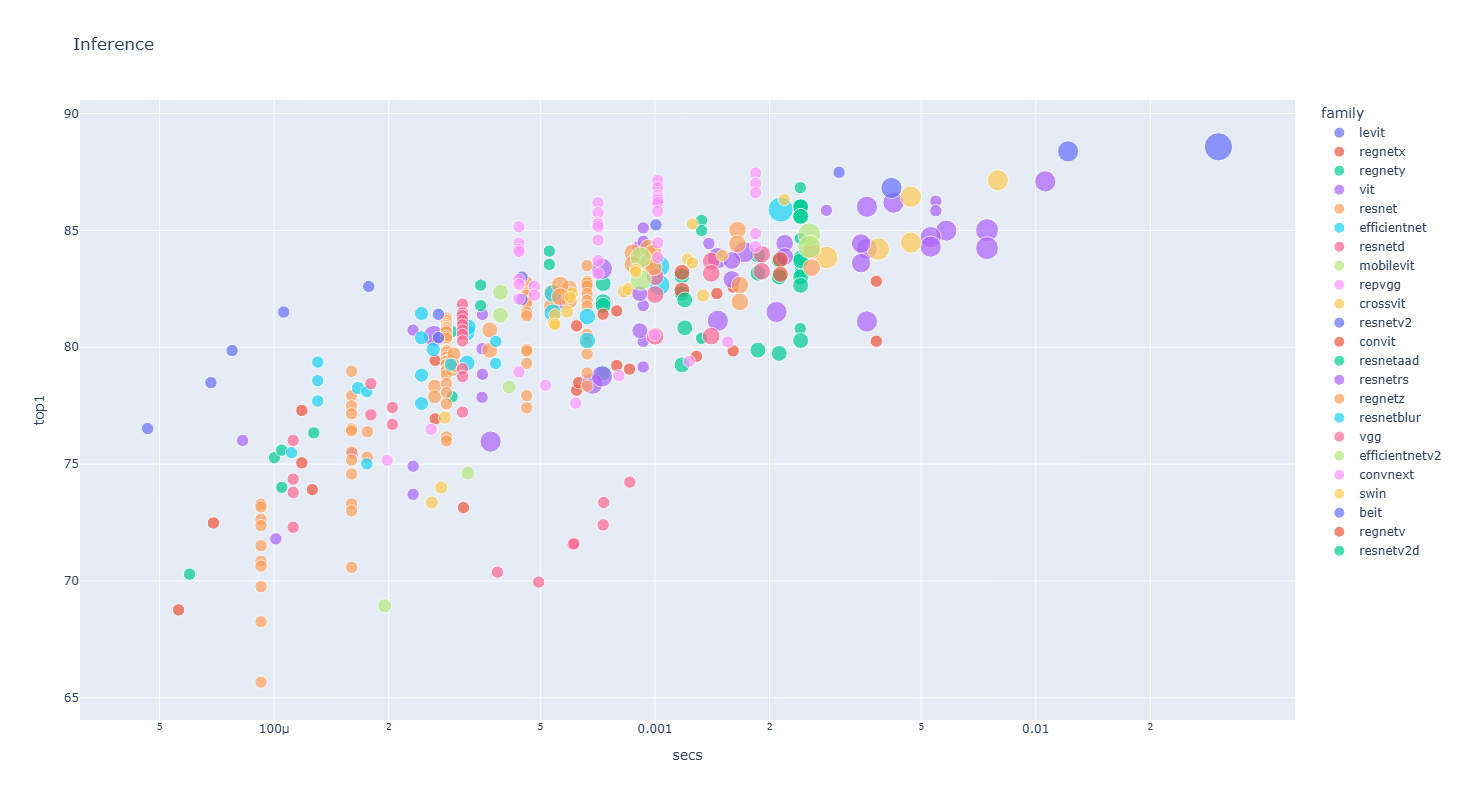

In [24]:
show_all(df, 'Inference', 'infer_img_size')

In [26]:
from ipywidgets import interact
from fastai.basics import *

plt.rc('figure', dpi=90)

def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

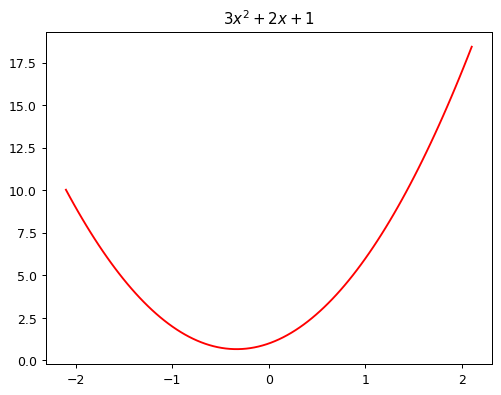

In [27]:
def f(x): return 3*x**2 + 2*x + 1

plot_function(f, "$3x^2 + 2x + 1$")

In [28]:
def quad(a, b, c, x): return a*x**2 + b*x + c

In [29]:
def mk_quad(a,b,c): return partial(quad, a,b,c)

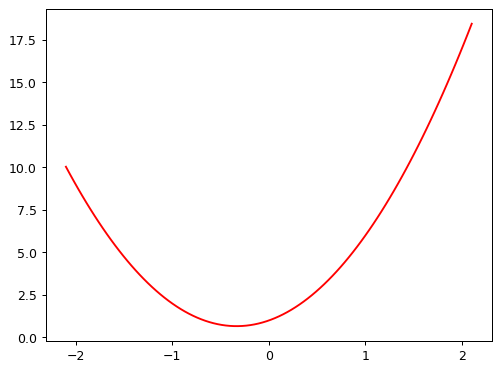

In [30]:
f2 = mk_quad(3,2,1)
plot_function(f2)

In [31]:
def noise(x, scale): return np.random.normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

In [32]:
np.random.seed(42)

x = torch.linspace(-2, 2, steps=20)[:,None]
y = add_noise(f(x), 0.15, 1.5)

C:\Users\modin\AppData\Local\Temp\ipykernel_8692\1958766108.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)


In [33]:
x[:5],y[:5]

(tensor([[-2.0000],
         [-1.7895],
         [-1.5789],
         [-1.3684],
         [-1.1579]]),
 tensor([[11.8690],
         [ 6.5433],
         [ 5.9396],
         [ 2.6304],
         [ 1.7947]], dtype=torch.float64))

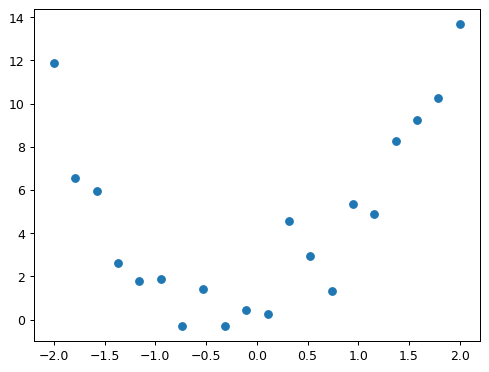

In [34]:
plt.scatter(x,y);

In [35]:
@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    plt.scatter(x,y)
    plot_function(mk_quad(a,b,c), ylim=(-3,13))

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [36]:
def mae(preds, acts): return (torch.abs(preds-acts)).mean()

In [37]:
@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    f = mk_quad(a,b,c)
    plt.scatter(x,y)
    loss = mae(f(x), y)
    plot_function(f, ylim=(-3,12), title=f"MAE: {loss:.2f}")

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [38]:
def quad_mae(params):
    f = mk_quad(*params)
    return mae(f(x), y)

In [39]:
quad_mae([1.1, 1.1, 1.1])

tensor(2.4219, dtype=torch.float64)

In [40]:
abc = torch.tensor([1.1,1.1,1.1])

In [41]:
abc.requires_grad_()

tensor([1.1000, 1.1000, 1.1000], requires_grad=True)

In [42]:
loss = quad_mae(abc)
loss

tensor(2.4219, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [43]:
loss.backward()

In [44]:
abc.grad

tensor([-1.3529, -0.0316, -0.5000])

In [45]:
with torch.no_grad():
    abc -= abc.grad*0.01
    loss = quad_mae(abc)
    
print(f'loss={loss:.2f}')

loss=2.40


In [46]:
for i in range(10):
    loss = quad_mae(abc)
    loss.backward()
    with torch.no_grad(): abc -= abc.grad*0.01
    print(f'step={i}; loss={loss:.2f}')

step=0; loss=2.40
step=1; loss=2.36
step=2; loss=2.30
step=3; loss=2.21
step=4; loss=2.11
step=5; loss=1.98
step=6; loss=1.85
step=7; loss=1.72
step=8; loss=1.58
step=9; loss=1.46


In [47]:
def rectified_linear(m,b,x):
    y = m*x+b
    return torch.clip(y, 0.)

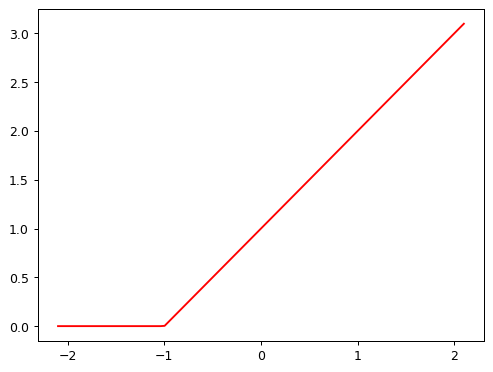

In [48]:
plot_function(partial(rectified_linear, 1,1))

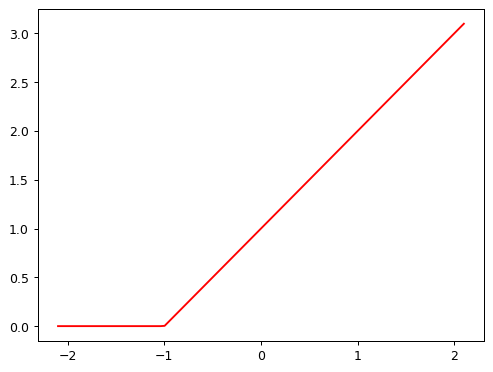

In [49]:
import torch.nn.functional as F
def rectified_linear2(m,b,x): return F.relu(m*x+b)
plot_function(partial(rectified_linear2, 1,1))

In [50]:
@interact(m=1.5, b=1.5)
    def plot_relu(m, b):
    plot_function(partial(rectified_linear, m,b), ylim=(-1,4))

interactive(children=(FloatSlider(value=1.5, description='m', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

interactive(children=(FloatSlider(value=-1.5, description='m1', max=1.5, min=-4.5), FloatSlider(value=-1.5, de…

In [76]:
#Getting started with NLP for absolute beginners
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

In [77]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
creds = ''

In [79]:
# for working with paths in Python, I recommend using `pathlib.Path`
from pathlib import Path

cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

In [80]:
path = Path('us-patent-phrase-to-phrase-matching')

In [82]:
if iskaggle:
    path = Path('../input/us-patent-phrase-to-phrase-matching')
    ! pip install -q datasets

In [83]:
!ls {path}

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [85]:
print(path)

us-patent-phrase-to-phrase-matching


In [88]:
df = pd.read_csv(r"C:\Users\modin\Downloads\us-patent-phrase-to-phrase-matching\train.csv")

In [90]:
import pandas as pd

df = pd.read_csv(r"C:\Users\modin\Downloads\us-patent-phrase-to-phrase-matching\train.csv")

In [91]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [92]:
df.describe(include='object')

C:\Users\modin\AppData\Local\Temp\ipykernel_8692\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


In [93]:
df['input'] = 'TEXT1: ' + df.context + '; TEXT2: ' + df.target + '; ANC1: ' + df.anchor

In [94]:
df.input.head()

0    TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement
1            TEXT1: A47; TEXT2: act of abating; ANC1: abatement
2           TEXT1: A47; TEXT2: active catalyst; ANC1: abatement
3       TEXT1: A47; TEXT2: eliminating process; ANC1: abatement
4             TEXT1: A47; TEXT2: forest region; ANC1: abatement
Name: input, dtype: str

In [96]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyarrow-24.0.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
     ---------------------------------------- 0.0/97.2 kB ? eta -:--:--
     ------------------------------------- -- 92.2/97.2 kB 2.6 MB/s eta 0:00:01
     ---------------------------------------- 97.2/97.2 kB 1.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ----------- ---------------------------- 153.6/555.1 kB 9.6 MB/s eta 0:00:01
   ---------------- ----------------------- 235.5/555.1 kB 3.6 MB/s eta 0:00:01
   ------------------------------------ --- 501.8/555.1 kB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 555.1/555.1 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/120.0 kB ? eta -:--:--
   ---------------------------------------- 120.0/120.0 kB 7.3 MB/s eta 0:00:00
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
from datasets import Dataset, DatasetDict

ds = Dataset.from_pandas(df)

In [98]:
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

In [99]:
model_nm = 'microsoft/deberta-v3-small'

In [101]:
%pip install transformers

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     -------------------------------------- 41.5/41.5 kB 664.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.1 MB 2.0 MB/s eta 0:00:06
   - -------------------------------------- 0.3/11.1 MB 3.2 MB/s eta 0:00:04
   - -------------------------------------- 0.3/11.1 MB 3.2 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/11.1 MB 3.7 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/11.1 MB 4.5 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/11.1 MB 4.9 MB/s eta 0:00:02
   ------ --------------------------------- 1.7/11.1 MB 5.2 MB/s eta 0:00:02
   ------- -------------------------------- 2.0/11.1 MB 5.5 MB/s eta 0:00:02
   ------- -------------------------------- 2.2/11.1 MB 5.2 MB/s eta 0:00:02
   ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
%pip install tiktoken

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/874.7 kB ? eta -:--:--
   ---------------------------------------- 10.2/874.7 kB ? eta -:--:--
   -- ------------------------------------ 61.4/874.7 kB 825.8 kB/s eta 0:00:01
   ------- -------------------------------- 163.8/874.7 kB 1.2 MB/s eta 0:00:01
   -------------- ------------------------- 327.7/874.7 kB 2.0 MB/s eta 0:00:01
   ---------------- ----------------------- 368.6/874.7 kB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 675.8/874.7 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------  870.4/874.7 kB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 874.7/874.7 kB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
%pip install sentencepiece

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.1/1.1 MB 1.3 MB/s eta 0:00:01
   -------- ------------------------------- 0.2/1.1 MB 1.8 MB/s eta 0:00:01
   ------------ --------------------------- 0.3/1.1 MB 2.1 MB/s eta 0:00:01
   --------------- ------------------------ 0.4/1.1 MB 2.3 MB/s eta 0:00:01
   ------------------------- -------------- 0.7/1.1 MB 2.5 MB/s eta 0:00:01
   -------------------------------- ------- 0.9/1.1 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
import sentencepiece
print(sentencepiece.__version__)

0.2.1


In [111]:
%pip install -U transformers tokenizers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
import sys
print(sys.executable)

import sentencepiece
print(sentencepiece.__version__)


C:\Program Files\Python312\python.exe
0.2.1


In [118]:
import transformers
import tokenizers
import sentencepiece

print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("sentencepiece:", sentencepiece.__version__)

transformers: 5.11.0
tokenizers: 0.22.2
sentencepiece: 0.2.1


In [119]:
import shutil

shutil.rmtree(
    r"C:\Users\modin\.cache\huggingface\hub\models--microsoft--deberta-v3-small",
    ignore_errors=True
)

In [121]:
%pip install -U "transformers==4.52.4" "tokenizers==0.21.1" "sentencepiece>=0.2.0"

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/10.5 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.3/10.5 MB 3.3 MB/s eta 0:00:04
   - -------------------------------------- 0.5/10.5 MB 3.3 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/10.5 MB 4.8 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/10.5 MB 4.3 MB/s eta 0:00:03
   ---- ----------------------------------- 1.2/10.5 MB 4.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.5/10.5 MB 4.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/10.5 MB 4.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.9/10.5 MB 4.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.0/10.5 MB 4.3 MB/s eta 0:00:02
   -------- ------------------------------- 2.2/10.5 MB 4.2 MB/s eta 0:00:02
   --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_nm = "microsoft/deberta-v3-small"

tokz = AutoTokenizer.from_pretrained(model_nm)

C:\Users\modin\AppData\Roaming\Python\Python312\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [3]:
tokz.tokenize("G'day folks, I'm Jeremy from fast.ai!")

['▁G',
 "'",
 'day',
 '▁folks',
 ',',
 '▁I',
 "'",
 'm',
 '▁Jeremy',
 '▁from',
 '▁fast',
 '.',
 'ai',
 '!']

In [4]:
tokz.tokenize("A platypus is an ornithorhynchus anatinus.")

['▁A',
 '▁platypus',
 '▁is',
 '▁an',
 '▁or',
 'ni',
 'tho',
 'rhynch',
 'us',
 '▁an',
 'at',
 'inus',
 '.']

In [5]:
def tok_func(x): return tokz(x["input"])

In [7]:
from datasets import load_dataset

ds = load_dataset("imdb")

README.md: 0.00B [00:00, ?B/s]

C:\Users\modin\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\modin\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [12]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [13]:
def tok_func(x):
    return tokz(x["text"])

In [14]:
tok_ds = ds.map(tok_func, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [16]:
row = tok_ds["train"][0]
row["text"], row["input_ids"]

('I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, e

In [17]:
tokz.vocab['▁of']

265

In [19]:
tok_ds = tok_ds.rename_columns({'label': 'labels'})

In [24]:
eval_df = pd.read_csv(r"C:\Users\modin\Downloads\us-patent-phrase-to-phrase-matching\test.csv")
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,el display,inorganic photoconductor drum,G02
freq,1,2,1,3


In [25]:
def f(x): return -3*x**2 + 2*x + 20

In [26]:
import numpy as np, matplotlib.pyplot as plt

def plot_function(f, min=-2.1, max=2.1, color='r'):
    x = np.linspace(min,max, 100)[:,None]
    plt.plot(x, f(x), color)

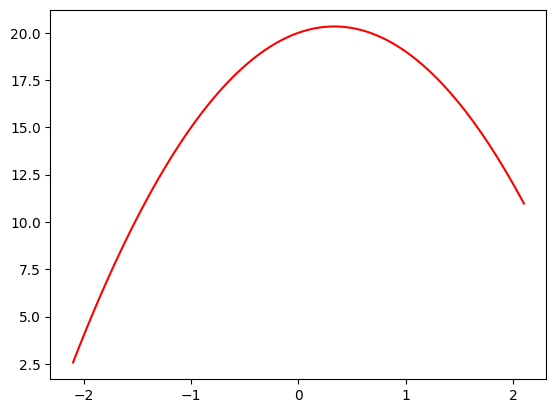

In [27]:
plot_function(f)

In [28]:
from numpy.random import normal,seed,uniform
np.random.seed(42)

In [29]:
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

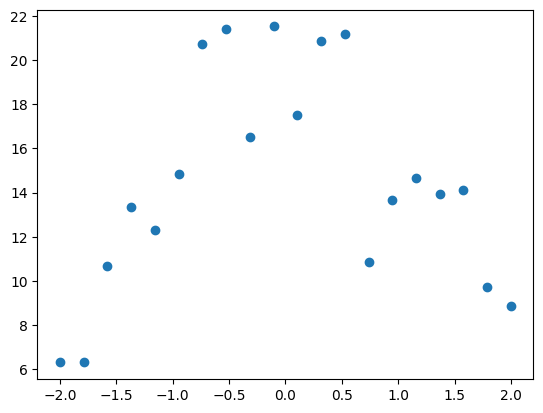

In [30]:
x = np.linspace(-2, 2, num=20)[:,None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y);

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_poly(degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)
    plt.scatter(x,y)
    plot_function(model.predict)

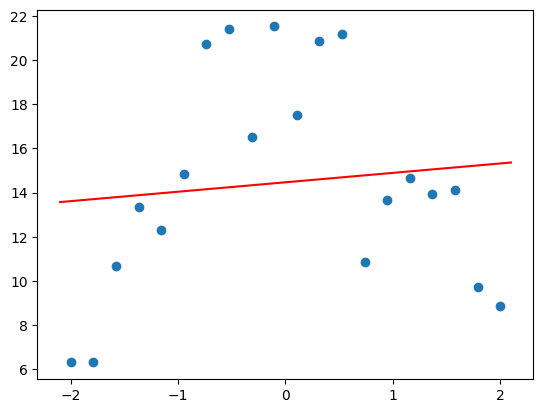

In [32]:
plot_poly(1)

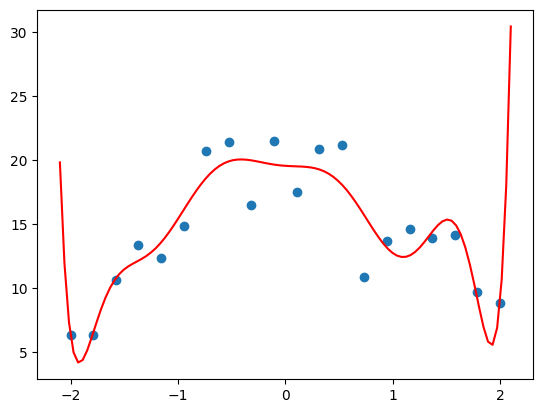

In [33]:
plot_poly(10)

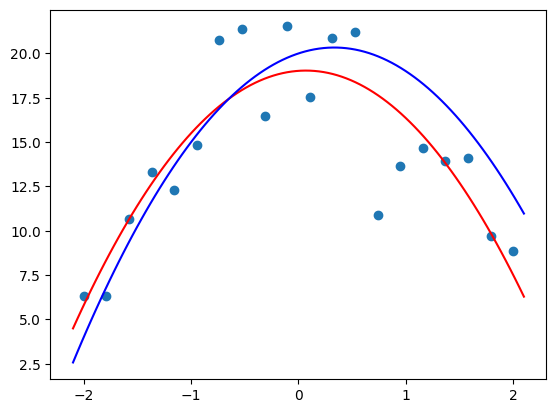

In [34]:
plot_poly(2)
plot_function(f, color='b')

In [37]:
dds = tok_ds["train"].train_test_split(test_size=0.25, seed=42)
dds

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18750
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6250
    })
})

In [42]:
def tok_func(x):
    return tokz(x["input"])

In [43]:
from datasets import Dataset

eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched=True)

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [44]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7506,3.0550,37.0,5.152778,1.048611,729.0,5.062500,33.92,-118.28,1.054
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
12888,2.5556,24.0,4.864905,1.129222,1631.0,2.395007,38.66,-121.35,1.057
13344,3.0057,32.0,4.212687,0.936567,1378.0,5.141791,34.05,-117.64,0.969
7173,1.9083,42.0,3.888554,1.039157,1535.0,4.623494,34.05,-118.19,1.192


In [45]:
np.set_printoptions(precision=2, suppress=True)

np.corrcoef(housing, rowvar=False)

array([[ 1.  , -0.12,  0.43, -0.08,  0.01, -0.07, -0.12,  0.04,  0.68],
       [-0.12,  1.  , -0.17, -0.06, -0.31,  0.  ,  0.03, -0.13,  0.12],
       [ 0.43, -0.17,  1.  ,  0.76, -0.09, -0.07,  0.12, -0.03,  0.21],
       [-0.08, -0.06,  0.76,  1.  , -0.08, -0.07,  0.09,  0.  , -0.04],
       [ 0.01, -0.31, -0.09, -0.08,  1.  ,  0.16, -0.15,  0.13,  0.  ],
       [-0.07,  0.  , -0.07, -0.07,  0.16,  1.  , -0.16,  0.17, -0.27],
       [-0.12,  0.03,  0.12,  0.09, -0.15, -0.16,  1.  , -0.93, -0.16],
       [ 0.04, -0.13, -0.03,  0.  ,  0.13,  0.17, -0.93,  1.  , -0.03],
       [ 0.68,  0.12,  0.21, -0.04,  0.  , -0.27, -0.16, -0.03,  1.  ]])

In [46]:
np.corrcoef(housing.MedInc, housing.MedHouseVal)


array([[1.  , 0.68],
       [0.68, 1.  ]])

In [47]:
def corr(x,y): return np.corrcoef(x,y)[0][1]

corr(housing.MedInc, housing.MedHouseVal)


np.float64(0.6760250732906004)

In [48]:
def show_corr(df, a, b):
    x,y = df[a],df[b]
    plt.scatter(x,y, alpha=0.5, s=4)
    plt.title(f'{a} vs {b}; r: {corr(x, y):.2f}')

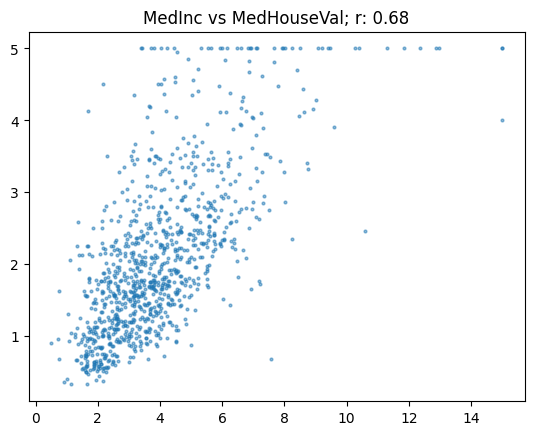

In [49]:
show_corr(housing, 'MedInc', 'MedHouseVal')

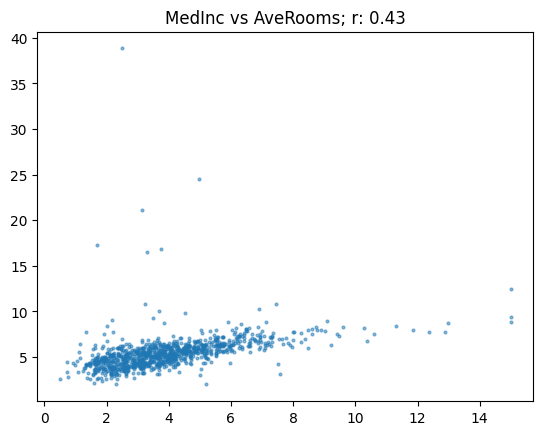

In [50]:
show_corr(housing, 'MedInc', 'AveRooms')

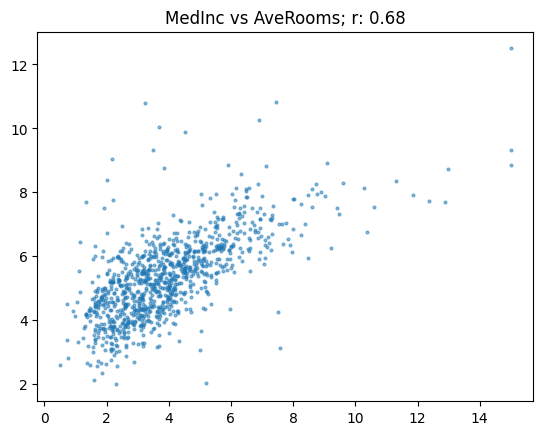

In [51]:
subset = housing[housing.AveRooms<15]
show_corr(subset, 'MedInc', 'AveRooms')

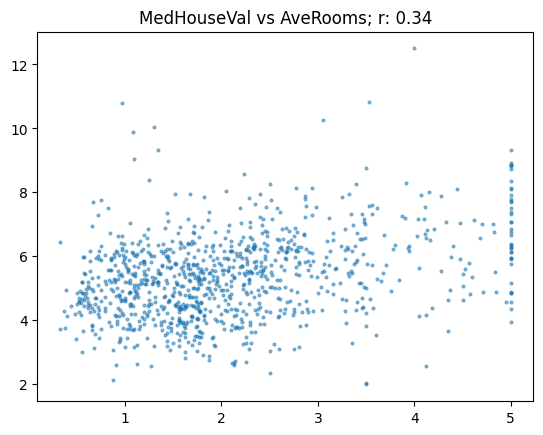

In [52]:
show_corr(subset, 'MedHouseVal', 'AveRooms')

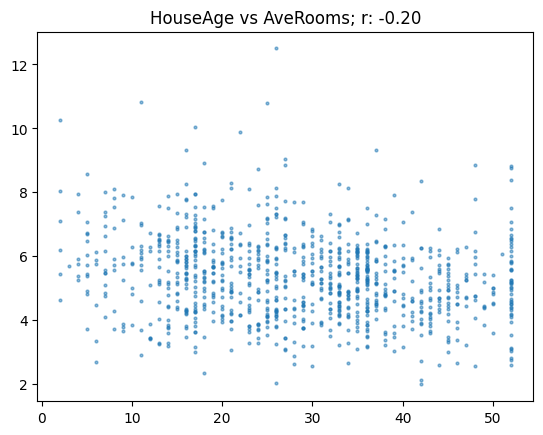

In [53]:
show_corr(subset, 'HouseAge', 'AveRooms')

In [54]:
    def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

In [57]:
bs = 128
epochs = 4

In [58]:
lr = 8e-5

In [4]:
lr = 2e-5
bs = 16
epochs = 3

In [6]:
evaluation_strategy="epoch"

In [7]:
args = TrainingArguments(
    output_dir='outputs',
    learning_rate=lr,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    fp16=True,
    per_device_train_batch_size=bs,
    per_device_eval_batch_size=bs * 2,
    num_train_epochs=epochs,
    weight_decay=0.01,
    report_to='none'
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [18]:
import transformers
print(transformers.__version__)

5.11.0


In [19]:
pip install --upgrade transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# Uninstall old version
!pip uninstall -y transformers

# Install a specific stable release
!pip install transformers==4.41.2

Found existing installation: transformers 5.11.0
Uninstalling transformers-5.11.0:
  Successfully uninstalled transformers-5.11.0
Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/43.8 kB ? eta -:--:--
     ----------------- -------------------- 20.5/43.8 kB 320.0 kB/s eta 0:00:01
     ----------------------------------- -- 41.0/43.8 kB 388.9 kB/s eta 0:00:01
     -------------------------------------- 43.8/43.8 kB 268.6 kB/s eta 0:00:00
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.1 MB 1.7 MB/s eta 0:00:06
   - -------------------------------------- 0.3/9.1 MB 2.6 MB/s eta 0:00:04
   - -------------------------------------- 0.5/9.1 MB 3.1 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/9.1 MB 2.7 MB/s eta 0:00:04
   --- ----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# 1. Imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset

# 2. Load dataset (IMDb reviews)
raw_datasets = load_dataset("imdb")

# 3. Define model name and tokenizer
model_nm = "distilbert-base-uncased"
tokz = AutoTokenizer.from_pretrained(model_nm)

# 4. Tokenize dataset
def tokenize_function(example):
    return tokz(example["text"], truncation=True, padding="max_length")

dds = raw_datasets.map(tokenize_function, batched=True)

# 5. Subset for faster training (optional)
small_train = dds["train"].shuffle(seed=42).select(range(1000))
small_test = dds["test"].shuffle(seed=42).select(range(500))

# 6. Load model
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=2)

# 7. Training arguments
args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,   # keep small for speed
    weight_decay=0.01,
)

# 8. Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=small_train,
    eval_dataset=small_test,
    tokenizer=tokz,
)

# 9. Train
trainer.train()

# 10. Evaluate
trainer.evaluate()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\modin\AppData\Roaming\Python\Python312\site-packages\transformers\training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\modin\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.466002


C:\Users\modin\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.4660017490386963,
 'eval_runtime': 162.321,
 'eval_samples_per_second': 3.08,
 'eval_steps_per_second': 0.197,
 'epoch': 1.0}